In [1]:
import pandas as pd
import numpy as np
import glob
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import joblib

In [2]:
files = glob.glob("data/*.csv")
df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

In [3]:
df.tail()

,flow_id,timestamp,src_ip,src_port,dst_ip,dst_port,protocol,duration,packets_count,fwd_packets_count,...,bwd_packets_IAT_mean,bwd_packets_IAT_std,bwd_packets_IAT_max,bwd_packets_IAT_min,bwd_packets_IAT_total,subflow_fwd_packets,subflow_bwd_packets,subflow_fwd_bytes,subflow_bwd_bytes,label
2342314,192.168.10.3_56540_40.70.221.249_443_TCP_2017-...,2017-07-05 16:08:36.272705,192.168.10.3,56540,40.70.221.249,443,TCP,0.000000,1,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,Benign
2342315,192.168.10.14_58668_40.70.221.249_443_TCP_2017...,2017-07-05 16:08:50.020081,192.168.10.14,58668,40.70.221.249,443,TCP,0.000000,1,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,Benign
2342316,209.48.71.129_80_192.168.10.15_58122_TCP_2017-...,2017-07-05 16:08:52.935367,209.48.71.129,80,192.168.10.15,58122,TCP,0.984902,34,34,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,Benign
2342317,192.168.10.3_138_192.168.10.255_138_UDP_2017-0...,2017-07-05 16:09:52.273065,192.168.10.3,138,192.168.10.255,138,UDP,0.000020,9,9,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,Benign
2342318,192.168.10.14_58669_192.168.10.3_445_TCP_2017-...,2017-07-05 16:10:14.557249,192.168.10.14,58669,192.168.10.3,445,TCP,0.003557,35,19,...,0.000222,0.000319,0.001016,0.000002,0.003335,0.0,0.0,0.0,0.0,Benign


In [4]:
t = "bwd_total_payload_bytes	payload_bytes_max	payload_bytes_min	payload_bytes_mean	payload_bytes_std	payload_bytes_variance	fwd_payload_bytes_max	fwd_payload_bytes_min	fwd_payload_bytes_mean	fwd_payload_bytes_std	fwd_payload_bytes_variance	bwd_payload_bytes_max	bwd_payload_bytes_min	bwd_payload_bytes_mean	bwd_payload_bytes_std	bwd_payload_bytes_variance	max_header_bytes	min_header_bytes	mean_header_bytes	std_header_bytes	fwd_total_header_bytes	fwd_max_header_bytes	fwd_min_header_bytes	fwd_mean_header_bytes	fwd_std_header_bytes	bwd_total_header_bytes	bwd_max_header_bytes	bwd_min_header_bytes	bwd_mean_header_bytes	bwd_std_header_bytes	fwd_avg_segment_size	bwd_avg_segment_size	avg_segment_size	fwd_init_win_bytes	bwd_init_win_bytes	active_min	active_max	active_mean	active_std	idle_min	idle_max	idle_mean	idle_std	bytes_rate	fwd_bytes_rate	bwd_bytes_rate	packets_rate	bwd_packets_rate	fwd_packets_rate	down_up_rate	avg_fwd_bytes_per_bulk	avg_fwd_packets_per_bulk	avg_fwd_bulk_rate	avg_bwd_bytes_per_bulk	avg_bwd_packets_bulk_rate	avg_bwd_bulk_rate	fwd_bulk_state_count	fwd_bulk_total_size	fwd_bulk_per_packet	fwd_bulk_duration	bwd_bulk_state_count	bwd_bulk_total_size	bwd_bulk_per_packet	bwd_bulk_duration	fwd_fin_flag_counts	fwd_psh_flag_counts	fwd_urg_flag_counts	fwd_ece_flag_counts	fwd_syn_flag_counts	fwd_ack_flag_counts	fwd_cwr_flag_counts	fwd_rst_flag_counts	bwd_fin_flag_counts	bwd_psh_flag_counts	bwd_urg_flag_counts	bwd_ece_flag_counts	bwd_syn_flag_counts	bwd_ack_flag_counts	bwd_cwr_flag_counts	bwd_rst_flag_counts	packets_IAT_mean	packet_IAT_std	packet_IAT_max	packet_IAT_min	packet_IAT_total	fwd_packets_IAT_mean	fwd_packets_IAT_std	fwd_packets_IAT_max	fwd_packets_IAT_min	fwd_packets_IAT_total	bwd_packets_IAT_mean	bwd_packets_IAT_std	bwd_packets_IAT_max	bwd_packets_IAT_min	bwd_packets_IAT_total	subflow_fwd_packets	subflow_bwd_packets	subflow_fwd_bytes	subflow_bwd_bytes"
x = (t.split("\t"))

In [5]:
df.drop(["src_ip", "dst_ip", "flow_id", "timestamp"] + x, axis = 1, inplace = True)

In [6]:
df["protocol"] = df["protocol"].map({"TCP":0, "UDP":1})

In [7]:
df.head()

,src_port,dst_port,protocol,duration,packets_count,fwd_packets_count,bwd_packets_count,total_payload_bytes,fwd_total_payload_bytes,total_header_bytes,fin_flag_counts,psh_flag_counts,urg_flag_counts,ece_flag_counts,syn_flag_counts,ack_flag_counts,cwr_flag_counts,rst_flag_counts,label
0,44904,444,0,5.042544,9,4,5,1823,517,304,2,2,0,0,2,8,0,0,Heartbleed
1,44906,444,0,5.011057,9,4,5,1823,517,304,2,2,0,0,2,8,0,0,Heartbleed
2,44990,444,0,5.027478,9,4,5,1823,517,304,2,2,0,0,2,8,0,0,Heartbleed
3,44994,444,0,5.016771,9,4,5,1823,517,304,2,2,0,0,2,8,0,0,Heartbleed
4,44904,444,0,0.000000,1,1,0,0,0,20,0,0,0,0,0,0,0,1,Heartbleed


In [8]:
df_shuffled = df.sample(frac=1).reset_index(drop=True)

In [9]:
df_shuffled.tail()

,src_port,dst_port,protocol,duration,packets_count,fwd_packets_count,bwd_packets_count,total_payload_bytes,fwd_total_payload_bytes,total_header_bytes,fin_flag_counts,psh_flag_counts,urg_flag_counts,ece_flag_counts,syn_flag_counts,ack_flag_counts,cwr_flag_counts,rst_flag_counts,label
2342314,4477,53,1,0.000194,4,2,2,322,80,32,0,0,0,0,0,0,0,0,Benign
2342315,43258,443,0,0.000000,1,0,1,0,0,20,0,0,0,0,0,0,0,1,Benign
2342316,44288,80,0,0.000000,1,1,0,0,0,20,0,0,0,0,0,0,0,1,DoS_Hulk
2342317,36536,80,0,0.000000,1,1,0,0,0,20,0,0,0,0,0,0,0,1,DoS_Hulk
2342318,58258,53,1,0.000207,4,2,2,176,72,32,0,0,0,0,0,0,0,0,Benign


In [10]:
X = df_shuffled.drop("label", axis = 1)

In [11]:
X

,src_port,dst_port,protocol,duration,packets_count,fwd_packets_count,bwd_packets_count,total_payload_bytes,fwd_total_payload_bytes,total_header_bytes,fin_flag_counts,psh_flag_counts,urg_flag_counts,ece_flag_counts,syn_flag_counts,ack_flag_counts,cwr_flag_counts,rst_flag_counts
0,59328,1277,0,0.000043,2,1,1,0,0,44,0,0,0,0,1,1,0,1
1,17396,53,1,0.031346,4,2,2,264,82,32,0,0,0,0,0,0,0,0
2,34798,443,0,5.378592,13,7,6,803,635,432,2,4,0,0,2,12,0,0
3,43132,80,0,11.648613,11,6,5,3926,401,368,1,2,0,0,2,10,0,0
4,57576,80,0,0.372230,15,9,6,12269,674,496,1,3,0,0,2,14,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2342314,4477,53,1,0.000194,4,2,2,322,80,32,0,0,0,0,0,0,0,0
2342315,43258,443,0,0.000000,1,0,1,0,0,20,0,0,0,0,0,0,0,1
2342316,44288,80,0,0.000000,1,1,0,0,0,20,0,0,0,0,0,0,0,1
2342317,36536,80,0,0.000000,1,1,0,0,0,20,0,0,0,0,0,0,0,1


In [12]:
Y = df_shuffled["label"]
Y

0              Port_Scan
1                 Benign
2                 Benign
3          DoS_GoldenEye
4               DoS_Hulk
               ...      
2342314           Benign
2342315           Benign
2342316         DoS_Hulk
2342317         DoS_Hulk
2342318           Benign
Name: label, Length: 2342319, dtype: object

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state = 42)

In [14]:
model = HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, max_iter=500)

In [22]:
model.fit(X_train, Y_train)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",500
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",4
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dtyp

In [23]:
y_pred = model.predict(X_test)

In [24]:
report = classification_report(Y_test, y_pred, output_dict=True)


In [28]:
def report_plot(report):
    classes = [
        c for c in report.keys()
        if c not in ('accuracy', 'macro avg', 'weighted avg')
    ]
    
    precision = [report[c]['precision'] for c in classes]
    x = np.arange(len(classes))
    
    fig, axs = plt.subplots(1, 1, figsize=(10, 5), sharex=True)
    
    axs.bar(x, precision)
    axs.set_title("Precision per Class")
    axs.set_ylim(0, 1)
    
    axs.set_xticks(x)
    axs.set_xticklabels(classes, rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()



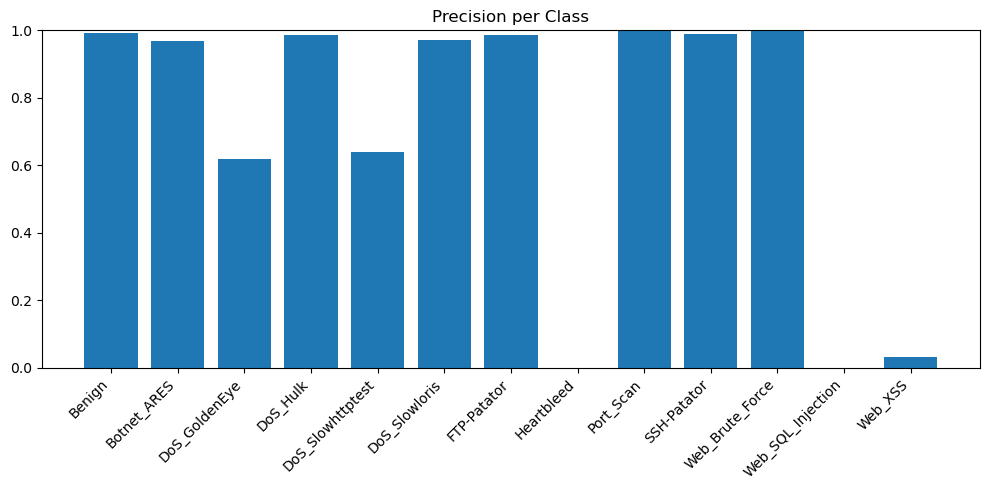

In [26]:
report_plot(report)

In [15]:
param_grid = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_iter": [200, 300, 500],
    "l2_regularization": [0.0, 1.0, 5.0]
}

In [16]:
grid = GridSearchCV (
    estimator=model,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=2
)

In [17]:
best_pred = grid.fit(X_train, Y_train)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
[CV] END l2_regularization=0.0, learning_rate=0.03, max_depth=4, max_iter=200; total time=  50.4s
[CV] END l2_regularization=0.0, learning_rate=0.03, max_depth=4, max_iter=300; total time=  37.5s
[CV] END l2_regularization=0.0, learning_rate=0.03, max_depth=4, max_iter=500; total time= 1.2min
[CV] END l2_regularization=0.0, learning_rate=0.03, max_depth=6, max_iter=200; total time= 1.2min
[CV] END l2_regularization=0.0, learning_rate=0.03, max_depth=6, max_iter=500; total time=  47.5s
[CV] END l2_regularization=0.0, learning_rate=0.03, max_depth=8, max_iter=200; total time= 1.3min
[CV] END l2_regularization=0.0, learning_rate=0.03, max_depth=8, max_iter=300; total time= 1.5min
[CV] END l2_regularization=0.0, learning_rate=0.05, max_depth=4, max_iter=200; total time=  25.7s
[CV] END l2_regularization=0.0, learning_rate=0.05, max_depth=4, max_iter=300; total time=  30.5s
[CV] END l2_regularization=0.0, learning_rate=0.05, max_

In [18]:
grid.best_params_

{'l2_regularization': 1.0,
 'learning_rate': 0.03,
 'max_depth': 4,
 'max_iter': 500}

In [19]:
bestModel = HistGradientBoostingClassifier(l2_regularization = 1.0, max_depth=4, learning_rate=0.03, max_iter=500)

In [21]:
yx_pred = bestModel.fit(X_train, Y_train)

In [25]:
pred = bestModel.predict(X_test)

In [26]:
report_bestmodel = classification_report(Y_test, pred, output_dict=True)

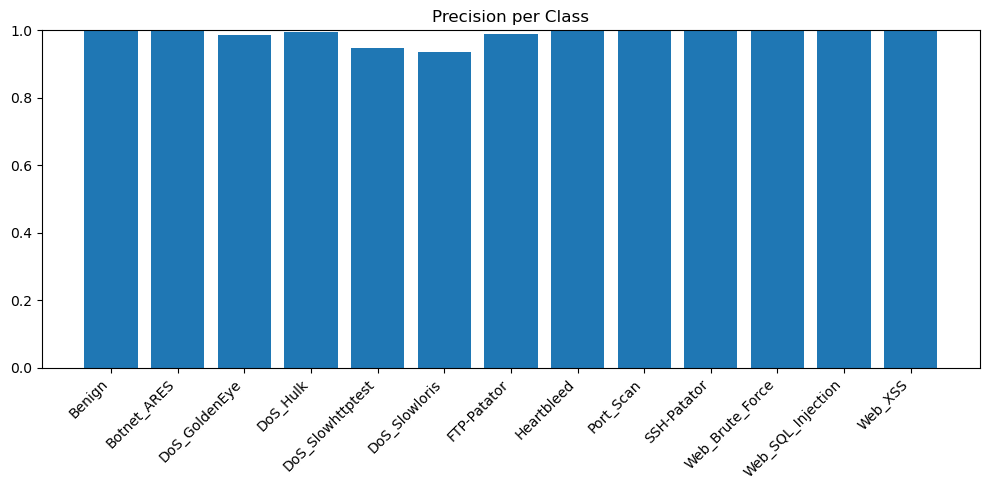

In [29]:
report_plot(report_bestmodel)

In [30]:
joblib.dump(bestModel, "bestmodel.pkl")

['bestmodel.pkl']